In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

%matplotlib inline


## Task 1 — Laplacian in the Frequency Domain


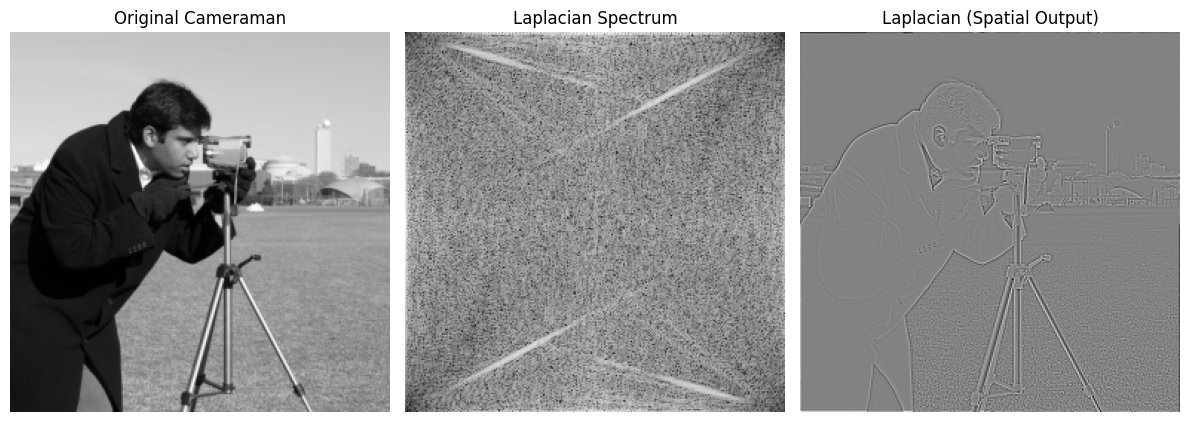

In [5]:
# --- Code from the lab manual ---
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))   # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)   # column vector of frequencies for rows
v = np.fft.fftfreq(N).reshape(1, -1)   # row vector of frequencies for columns

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain (pointwise multiplication)
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)'); plt.axis('off')

plt.tight_layout(); plt.show()

### Assessment Task — Sobel Filter in the Frequency Domain

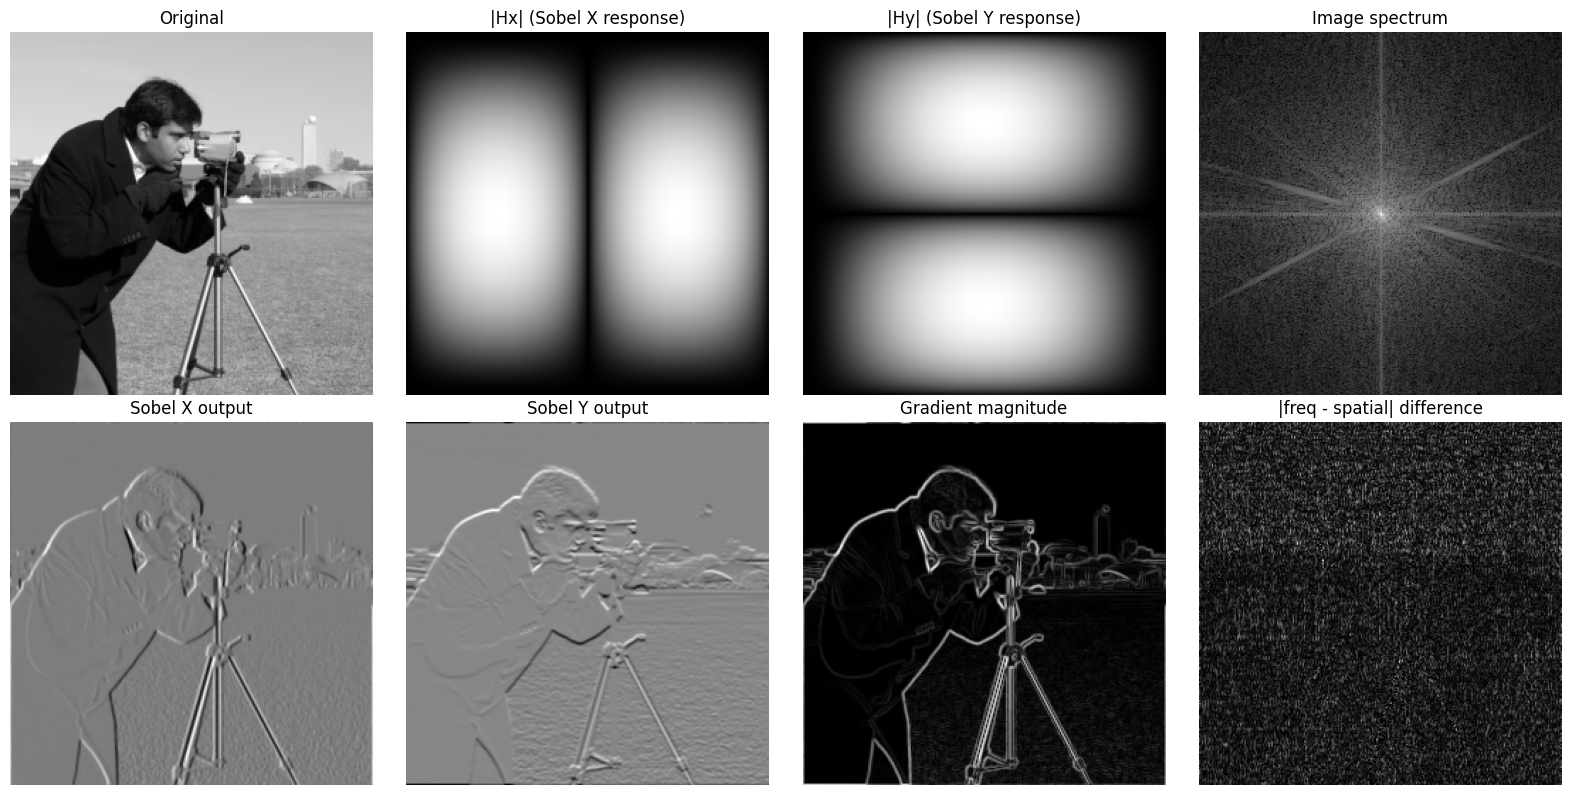

In [7]:

def center_embed_kernel(kernel, shape):
    M, N = shape
    kh, kw = kernel.shape
    padded = np.zeros((M, N))
    r0, c0 = M // 2 - kh // 2, N // 2 - kw // 2
    padded[r0:r0 + kh, c0:c0 + kw] = kernel      # kernel centre at image centre
    padded = ifftshift(padded)                    # move kernel centre to (0, 0)
    return fft2(padded)                           # frequency response

# Sobel kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=float)

# Image
image = resize(data.camera(), (256, 256))
M, N = image.shape

# Steps 1-3: frequency responses of the kernels
Hx = center_embed_kernel(sobel_x, (M, N))
Hy = center_embed_kernel(sobel_y, (M, N))

# Step 4: FFT of image and pointwise multiplication
F = fft2(image)
Gx = F * Hx
Gy = F * Hy

# Step 5: inverse FFT
gx = np.real(ifft2(Gx))
gy = np.real(ifft2(Gy))
magnitude = np.sqrt(gx**2 + gy**2)

# Plot
plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1); plt.imshow(image, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(2, 4, 2); plt.imshow(np.log(1 + np.abs(fftshift(Hx))), cmap='gray'); plt.title('|Hx| (Sobel X response)'); plt.axis('off')
plt.subplot(2, 4, 3); plt.imshow(np.log(1 + np.abs(fftshift(Hy))), cmap='gray'); plt.title('|Hy| (Sobel Y response)'); plt.axis('off')
plt.subplot(2, 4, 4); plt.imshow(np.log(1 + np.abs(fftshift(F))), cmap='gray'); plt.title('Image spectrum'); plt.axis('off')
plt.subplot(2, 4, 5); plt.imshow(gx, cmap='gray'); plt.title('Sobel X output'); plt.axis('off')
plt.subplot(2, 4, 6); plt.imshow(gy, cmap='gray'); plt.title('Sobel Y output'); plt.axis('off')
plt.subplot(2, 4, 7); plt.imshow(magnitude, cmap='gray'); plt.title('Gradient magnitude'); plt.axis('off')


from scipy.signal import convolve2d
gx_sp = convolve2d(image, sobel_x, mode='same', boundary='wrap')
plt.subplot(2, 4, 8); plt.imshow(np.abs(gx - gx_sp), cmap='gray'); plt.title('|freq - spatial| difference'); plt.axis('off')
plt.tight_layout(); plt.show()
